In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc và làm sạch dữ liệu
df = pd.read_csv("../data/raw/train.csv")

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True, errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True, errors="coerce")
df = df.dropna(subset=["Postal Code"]).copy()

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Quarter"] = df["Order Date"].dt.quarter
df["DayOfWeek"] = df["Order Date"].dt.day_name()

# Tạo cột Log_Sales
df["Log_Sales"] = np.log1p(df["Sales"])

# Kiểm tra kết quả
print("=== So sánh Sales gốc và Log_Sales ===")
print("\nSales gốc:")
print(df["Sales"].describe().round(2))

print("\nLog_Sales:")
print(df["Log_Sales"].describe().round(2))
print("\nKích thước dữ liệu hiện tại:", df.shape)

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/train.csv'

In [1]:
import numpy as np

# 1. Tạo cột Log_Sales (dùng log1p để an toàn với giá trị 0)
df['Log_Sales'] = np.log1p(df['Sales'])

# 2. Kiểm tra kết quả
print("=== So sánh Sales gốc và Log_Sales ===")
print("\nSales gốc:")
print(df['Sales'].describe().round(2))

print("\nLog_Sales:")
print(df['Log_Sales'].describe().round(2))

# 3. Trực quan hóa để thấy sự khác biệt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Sales'], bins=50, kde=True, ax=axes[0], color="#2874A6")
axes[0].set_title("Phân bố Sales gốc (có outliers)")
axes[0].set_xlabel("Sales (USD)")

sns.histplot(df['Log_Sales'], bins=50, kde=True, ax=axes[1], color="#196F3D")
axes[1].set_title("Phân bố Log_Sales (đã giảm ảnh hưởng outliers)")
axes[1].set_xlabel("Log(Sales)")

plt.tight_layout()
plt.savefig("../reports/figures/11_sales_vs_log_sales.png", dpi=150)
plt.show()

NameError: name 'df' is not defined

In [3]:
import os

print("Thư mục hiện tại của notebook:")
print(os.getcwd())

print("\nCác thư mục/file trong thư mục hiện tại:")
print(os.listdir())

print("\nThử liệt kê thư mục cha:")
print(os.listdir(".."))

Thư mục hiện tại của notebook:
c:\Users\viloc\Thư mục mới (3)\notebooks\notebooks

Các thư mục/file trong thư mục hiện tại:
['03_xu_ly_outliers.ipynb']

Thử liệt kê thư mục cha:
['01_doc_va_kham_pha_du_lieu.ipynb', '02_eda_phan_tich_kham_pha.ipynb', 'notebooks']


In [4]:
df = pd.read_csv("../../data/raw/train.csv")


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu (đi lên 2 cấp vì đang ở notebooks/notebooks)
df = pd.read_csv("../../data/raw/train.csv")

# Làm sạch dữ liệu
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True, errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True, errors="coerce")
df = df.dropna(subset=["Postal Code"]).copy()

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Quarter"] = df["Order Date"].dt.quarter
df["DayOfWeek"] = df["Order Date"].dt.day_name()

# Tạo cột Log_Sales
df["Log_Sales"] = np.log1p(df["Sales"])

# Kiểm tra
print("Kích thước dữ liệu:", df.shape)
print("\nSales gốc:")
print(df["Sales"].describe().round(2))
print("\nLog_Sales:")
print(df["Log_Sales"].describe().round(2))

Kích thước dữ liệu: (9789, 23)

Sales gốc:
count     9789.00
mean       230.12
std        625.30
min          0.44
25%         17.25
50%         54.38
75%        210.39
max      22638.48
Name: Sales, dtype: float64

Log_Sales:
count    9789.00
mean        4.16
std         1.59
min         0.37
25%         2.90
50%         4.01
75%         5.35
max        10.03
Name: Log_Sales, dtype: float64


### Quyết định xử lý Outliers

- Giữ nguyên toàn bộ dữ liệu gốc (bao gồm outliers) vì phản ánh đúng thực tế kinh doanh.
- Tạo thêm biến `Log_Sales = log(1 + Sales)` để sử dụng khi xây dựng mô hình, giúp giảm ảnh hưởng của outliers.

NameError: name 'df' is not defined

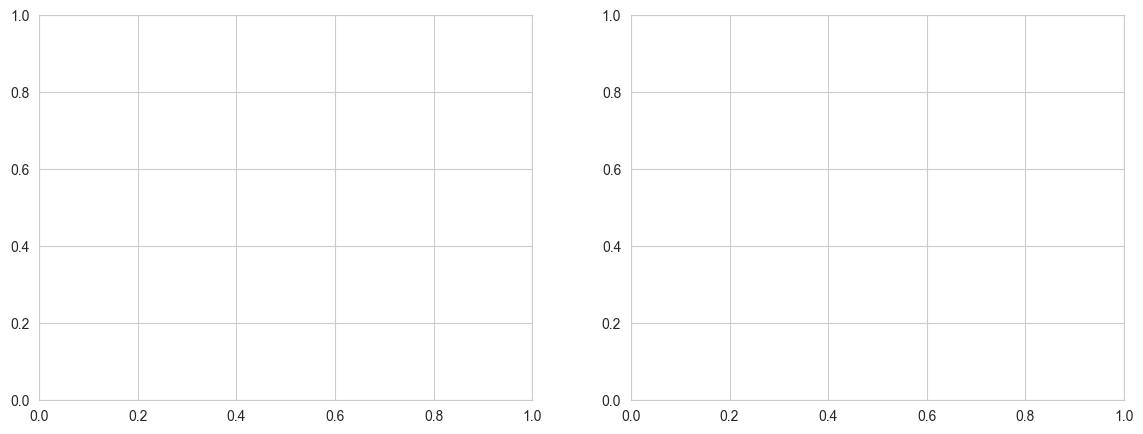

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style
sns.set_style("whitegrid")

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram Sales gốc
sns.histplot(df['Sales'], bins=50, kde=True, ax=axes[0], color="#2874A6")
axes[0].set_title("Phân bố Sales gốc (có outliers)", fontsize=13)
axes[0].set_xlabel("Sales (USD)")
axes[0].set_ylabel("Số lượng")

# Histogram Log_Sales
sns.histplot(df['Log_Sales'], bins=50, kde=True, ax=axes[1], color="#196F3D")
axes[1].set_title("Phân bố Log_Sales (đã giảm ảnh hưởng outliers)", fontsize=13)
axes[1].set_xlabel("Log(Sales)")
axes[1].set_ylabel("Số lượng")

plt.tight_layout()

# Lưu vào thư mục reports/figures (đi lên 2 cấp)
plt.savefig("../../reports/figures/11_sales_vs_log_sales.png", dpi=150, bbox_inches="tight")
plt.show()

print("Đã lưu biểu đồ thành công vào: reports/figures/11_sales_vs_log_sales.png")

Kích thước dữ liệu: (9789, 23)


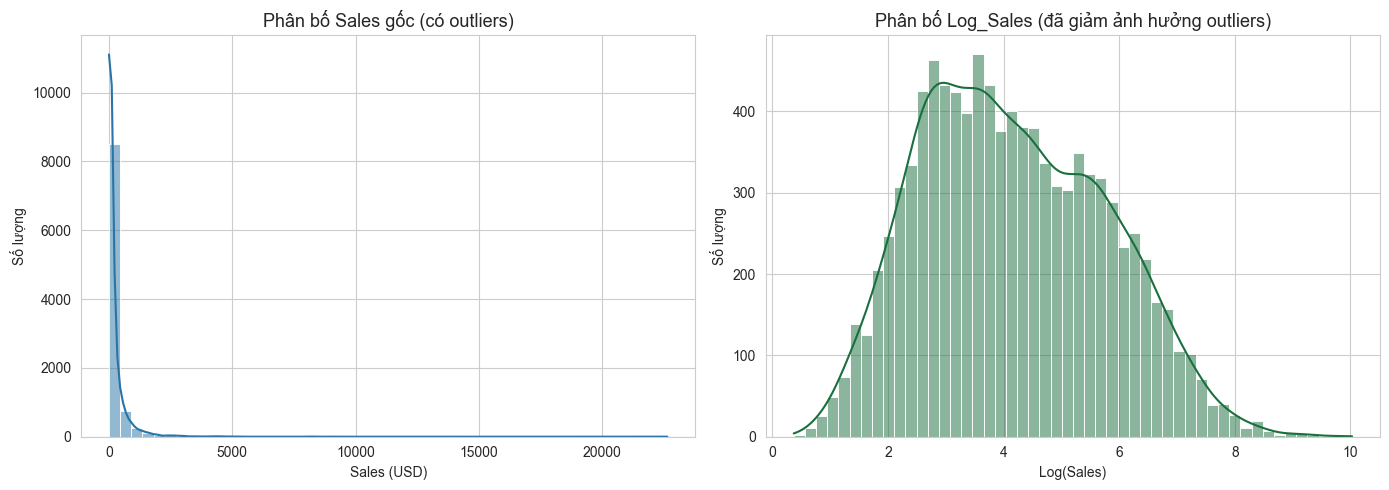

Đã lưu biểu đồ thành công!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Tạo thư mục nếu chưa có
os.makedirs("../../reports/figures", exist_ok=True)

# Đọc và xử lý dữ liệu
df = pd.read_csv("../../data/raw/train.csv")

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True, errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True, errors="coerce")
df = df.dropna(subset=["Postal Code"]).copy()

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Quarter"] = df["Order Date"].dt.quarter
df["DayOfWeek"] = df["Order Date"].dt.day_name()
df["Log_Sales"] = np.log1p(df["Sales"])

print("Kích thước dữ liệu:", df.shape)

# Vẽ biểu đồ so sánh
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Sales'], bins=50, kde=True, ax=axes[0], color="#2874A6")
axes[0].set_title("Phân bố Sales gốc (có outliers)", fontsize=13)
axes[0].set_xlabel("Sales (USD)")
axes[0].set_ylabel("Số lượng")

sns.histplot(df['Log_Sales'], bins=50, kde=True, ax=axes[1], color="#196F3D")
axes[1].set_title("Phân bố Log_Sales (đã giảm ảnh hưởng outliers)", fontsize=13)
axes[1].set_xlabel("Log(Sales)")
axes[1].set_ylabel("Số lượng")

plt.tight_layout()
plt.savefig("../../reports/figures/11_sales_vs_log_sales.png", dpi=150, bbox_inches="tight")
plt.show()

print("Đã lưu biểu đồ thành công!")